# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 2: Dimensioning Lossless Storage (41 points)

Consider the time series on wind and solar capacity factors and electricity demand in the Czech
Republic in 2019:

In [1]:
url = "https://tubcloud.tu-berlin.de/s/r6KpCsmwx5wA5A8/download/time-series-cz.csv"

The goal of this task is to dimension a lossless storage for different generation mixes of onshore wind and
solar to supply demand. This means that you should assume, for simplicity, that the storing electricity does not incur any losses.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**a)** Load the provided dataset as a `pandas.DataFrame` under the name `df` and such that its index contains the time stamps. Return the resulting `pandas.DataFrame`. **(1 point)**

In [3]:
# YOUR CODE HERE
df = pd.read_csv(url, index_col = 0)
df

,load_mw,pv_pu,wind_pu
timestamp,,,
2019-01-01 00:00:00,5719.26,0.0,0.1846
2019-01-01 01:00:00,5677.73,0.0,0.2293
2019-01-01 02:00:00,5622.20,0.0,0.2718
2019-01-01 03:00:00,5474.74,0.0,0.3146
2019-01-01 04:00:00,5432.51,0.0,0.3552
...,...,...,...
2019-12-31 19:00:00,6595.66,0.0,0.2784
2019-12-31 20:00:00,6255.85,0.0,0.2704
2019-12-31 21:00:00,6191.86,0.0,0.2636


In [4]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)

**b)** Convert the unit of the load to GW in a new column `load_gw` and rescale the onshore wind and solar capacity factor time series such that _for each of them_ the annual generation equals the annual load. Store the resulting time series in GW in new columns `wind_gw` and `pv_gw`, respectively. Return the modified `pandas.DataFrame`. **(3 points)**

In [5]:
# YOUR CODE HERE
df['load_gw'] = df['load_mw'] / 1000
wind_capacity_gw = df['load_gw'].sum() / df['wind_pu'].sum()
pv_capacity_gw = df['load_gw'].sum() / df['pv_pu'].sum()
df['wind_gw'] = df['wind_pu'] * wind_capacity_gw
df['pv_gw'] = df['pv_pu'] * pv_capacity_gw
df

,load_mw,pv_pu,wind_pu,load_gw,wind_gw,pv_gw
timestamp,,,,,,
2019-01-01 00:00:00,5719.26,0.0,0.1846,5.71926,6.093549,0.0
2019-01-01 01:00:00,5677.73,0.0,0.2293,5.67773,7.569073,0.0
2019-01-01 02:00:00,5622.20,0.0,0.2718,5.62220,8.971976,0.0
2019-01-01 03:00:00,5474.74,0.0,0.3146,5.47474,10.384782,0.0
2019-01-01 04:00:00,5432.51,0.0,0.3552,5.43251,11.724966,0.0
...,...,...,...,...,...,...
2019-12-31 19:00:00,6595.66,0.0,0.2784,6.59566,9.189838,0.0
2019-12-31 20:00:00,6255.85,0.0,0.2704,6.25585,8.925763,0.0
2019-12-31 21:00:00,6191.86,0.0,0.2636,6.19186,8.701298,0.0


In [6]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)

In [7]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [8]:
### AUTOGRADING CELL - DO NOT TOUCH!

**c)** Determine the residual load time series for the case where all power is supplied by (1) wind power only and (2) solar power only. 

1. Wind-only case. Return the result as a `pandas.Series` in GW. **(2 points)**

In [9]:
# YOUR CODE HERE
df['residual_load_wind'] = df['load_gw'] - df['wind_gw']
df['residual_load_wind']

timestamp
2019-01-01 00:00:00   -0.374289
2019-01-01 01:00:00   -1.891343
2019-01-01 02:00:00   -3.349776
2019-01-01 03:00:00   -4.910042
2019-01-01 04:00:00   -6.292456
                         ...   
2019-12-31 19:00:00   -2.594178
2019-12-31 20:00:00   -2.669913
2019-12-31 21:00:00   -2.509438
2019-12-31 22:00:00   -2.036748
2019-12-31 23:00:00   -1.426151
Name: residual_load_wind, Length: 8760, dtype: float64

In [10]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

2. Solar-only case. Return the result as a `pandas.Series` in GW. **(2 points)**

In [11]:
# YOUR CODE HERE
df['residual_load_solar'] = df['load_gw'] - df['pv_gw']
df['residual_load_solar']

timestamp
2019-01-01 00:00:00    5.71926
2019-01-01 01:00:00    5.67773
2019-01-01 02:00:00    5.62220
2019-01-01 03:00:00    5.47474
2019-01-01 04:00:00    5.43251
                        ...   
2019-12-31 19:00:00    6.59566
2019-12-31 20:00:00    6.25585
2019-12-31 21:00:00    6.19186
2019-12-31 22:00:00    6.07038
2019-12-31 23:00:00    5.82273
Name: residual_load_solar, Length: 8760, dtype: float64

In [12]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**d)** Plot the residual load duration curves for the wind-only and solar-only cases in a single figure. The x-axis should show the number of hours per year the residual load is exceeded. Add a dashed horizontal line at zero and label the figure appropriately. **(3 points)**

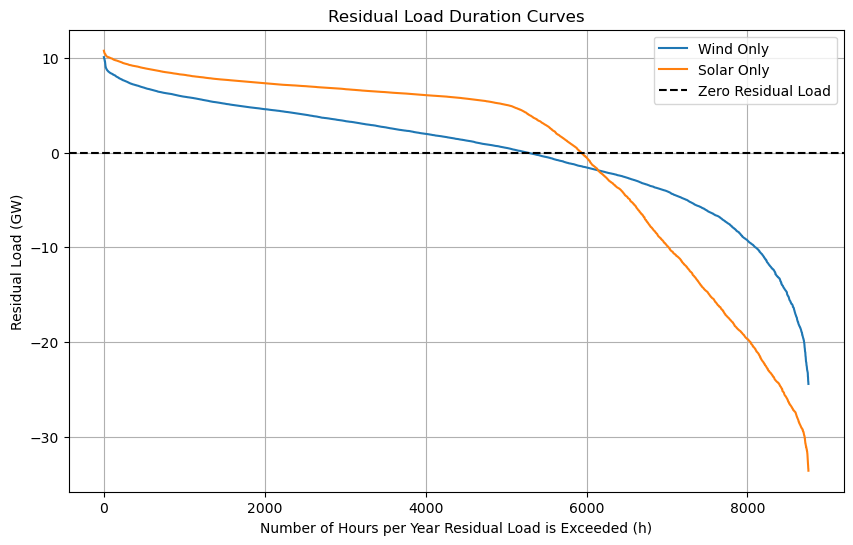

In [13]:
# YOUR CODE HERE
wind_duration = df['residual_load_wind'].sort_values(ascending=False).values
solar_duration = df['residual_load_solar'].sort_values(ascending=False).values
plt.figure(figsize=(10, 6))
plt.plot(wind_duration, label='Wind Only')
plt.plot(solar_duration, label='Solar Only')
plt.axhline(0, color='black', linestyle='--', label='Zero Residual Load')
plt.title('Residual Load Duration Curves')
plt.xlabel('Number of Hours per Year Residual Load is Exceeded (h)')
plt.ylabel('Residual Load (GW)')
plt.legend()
plt.grid(True)

plt.show()

**e)** Calculate the state of charge time series for (1) the wind-only case and (2) the solar-only case. For each case, choose the initial state of charge to be as small as possible while ensuring that the state of charge does not become negative.

1. Wind-only case. Return the result as a `pandas.Series` in GWh. **(2 points)**

In [14]:
# YOUR CODE HERE
soc_wind_initial = (-df['residual_load_wind']).cumsum().min()
soc_wind = (-df['residual_load_wind']).cumsum() - soc_wind_initial
soc_wind

timestamp
2019-01-01 00:00:00    1749.742530
2019-01-01 01:00:00    1751.633873
2019-01-01 02:00:00    1754.983649
2019-01-01 03:00:00    1759.893691
2019-01-01 04:00:00    1766.186147
                          ...     
2019-12-31 19:00:00    1740.725991
2019-12-31 20:00:00    1743.395904
2019-12-31 21:00:00    1745.905342
2019-12-31 22:00:00    1747.942089
2019-12-31 23:00:00    1749.368241
Name: residual_load_wind, Length: 8760, dtype: float64

In [15]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [16]:
### AUTOGRADING CELL - DO NOT TOUCH!

2. Solar-only case. Return the result as a `pandas.Series` in GWh. **(2 points)**

In [17]:
# YOUR CODE HERE
soc_solar_initial = (-df['residual_load_solar']).cumsum().min()
soc_solar = (-df['residual_load_solar']).cumsum() - soc_solar_initial
soc_solar

timestamp
2019-01-01 00:00:00    6589.988229
2019-01-01 01:00:00    6584.310499
2019-01-01 02:00:00    6578.688299
2019-01-01 03:00:00    6573.213559
2019-01-01 04:00:00    6567.781049
                          ...     
2019-12-31 19:00:00    6620.048309
2019-12-31 20:00:00    6613.792459
2019-12-31 21:00:00    6607.600599
2019-12-31 22:00:00    6601.530219
2019-12-31 23:00:00    6595.707489
Name: residual_load_solar, Length: 8760, dtype: float64

In [18]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [19]:
### AUTOGRADING CELL - DO NOT TOUCH!

**f)** Plot the state of charge profiles (in TWh) for the wind-only and solar-only cases in a single figure with appropriate labels. **(3 points)**

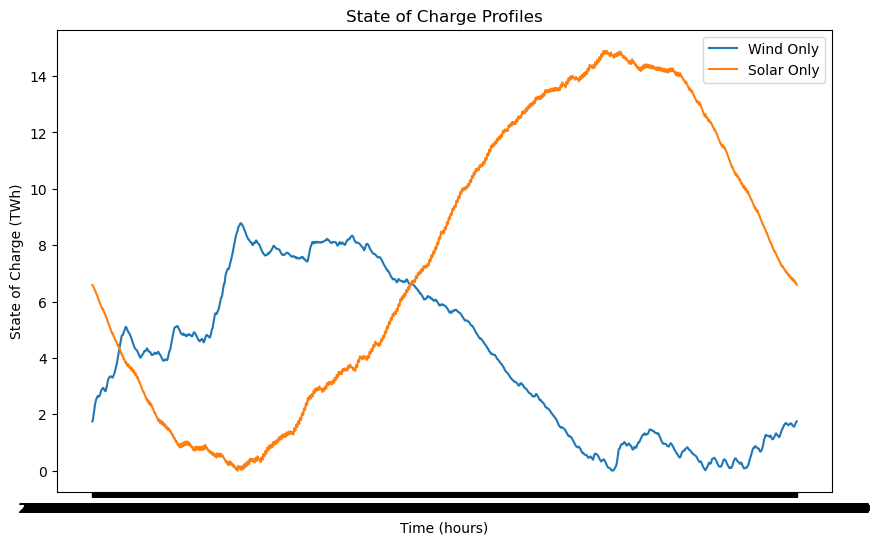

In [20]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.plot(soc_wind/1000, label='Wind Only')
plt.plot(soc_solar/1000, label='Solar Only')
plt.title('State of Charge Profiles')
plt.xlabel('Time (hours)')
plt.ylabel('State of Charge (TWh)')
plt.legend()

**g)** Determine the required energy storage capacity (in GWh), the charging power capacity (in GW), and the discharging power capacity (in GW) for (1) the wind-only case and (2) the solar-only case.

1. Wind-only case, energy storage capacity (in GWh). Return the value as a float. **(1 point)**

In [ ]:
# YOUR CODE HERE
storage_capacity_wind = soc_wind.max() - soc_wind.min()
storage_capacity_wind

# wind_discharging_gw = df['residual_load_wind'].max()

8780.998200364716

In [22]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

2. Wind-only case, charging power capacity (in GW). Return the value as a positive float. **(1 point)**

In [23]:
# YOUR CODE HERE
charging_power_capacity_wind = (-df['residual_load_wind']).max()
charging_power_capacity_wind

24.408996261839345

In [24]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

3. Wind-only case, discharging power capacity (in GW). Return the value as a positive float. **(1 point)**

In [25]:
# YOUR CODE HERE
discharging_power_capacity_wind = df['residual_load_wind'].max()
discharging_power_capacity_wind

10.067964182301957

In [26]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

4. Solar-only case, energy storage capacity (in GWh). Return the value as a float. **(1 point)**

In [27]:
# YOUR CODE HERE
storage_capacity_solar = soc_solar.max() - soc_solar.min()
storage_capacity_solar

14897.738357006237

In [28]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

5. Solar-only case, charging power capacity (in GW). Return the value as a positive float. **(1 point)**

In [29]:
# YOUR CODE HERE
charging_power_capacity_solar = (-df['residual_load_solar']).max()
charging_power_capacity_solar

33.565600001669985

In [30]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

6. Solar-only case, discharging power capacity (in GW). Return the value as a positive float. **(1 point)**

In [31]:
# YOUR CODE HERE
discharging_power_capacity_solar = df['residual_load_solar'].max()
discharging_power_capacity_solar

10.74619

In [32]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

Until now, we only considered the two extreme cases of wind-only and solar-only generation. In the following, we are going to analyze combinations of wind and solar generation.

**h)** Write a Python function that computes the residual load as a function of the solar generation share $\alpha \in [0, 1]$, where $\alpha = 0$ corresponds to the wind-only case and $\alpha = 1$ to the solar-only case. The function should take as input the `pandas.DataFrame` `df` and the solar generation share $\alpha$ and return the residual load time series as a `pandas.Series` in GW. **(3 points)**

In [33]:
def residual_load(df: pd.DataFrame, alpha: float) -> pd.Series:#
    # YOUR CODE HERE
    return df['load_gw'] - (1 - alpha) * df['wind_gw'] - alpha * df['pv_gw']

**i)** Apply the function from **h)** for solar generation shares $\alpha$ ranging from 0 to 1 in steps of 0.025 and store the resulting residual load time series in a new `pandas.DataFrame` where each column denotes a particular value for $\alpha$. Return the resulting `pandas.DataFrame`. **(2 points)**

In [34]:
# YOUR CODE HERE
df_alpha = pd.DataFrame()
for i in np.arange(0, 1.01, 0.025):
    df_alpha[f'alpha_{i}'] = residual_load(df, i)
df_alpha


,alpha_0.0,alpha_0.025,alpha_0.05,alpha_0.07500000000000001,alpha_0.1,alpha_0.125,alpha_0.15000000000000002,alpha_0.17500000000000002,alpha_0.2,alpha_0.225,...,alpha_0.775,alpha_0.8,alpha_0.8250000000000001,alpha_0.8500000000000001,alpha_0.875,alpha_0.9,alpha_0.925,alpha_0.9500000000000001,alpha_0.9750000000000001,alpha_1.0
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,-0.374289,-0.221951,-0.069612,0.082727,0.235065,0.387404,0.539743,0.692082,0.844420,0.996759,...,4.348211,4.500550,4.652889,4.805228,4.957566,5.109905,5.262244,5.414583,5.566921,5.71926
2019-01-01 01:00:00,-1.891343,-1.702116,-1.512889,-1.323663,-1.134436,-0.945209,-0.755982,-0.566755,-0.377528,-0.188302,...,3.974689,4.163915,4.353142,4.542369,4.731596,4.920823,5.110050,5.299276,5.488503,5.67773
2019-01-01 02:00:00,-3.349776,-3.125477,-2.901177,-2.676878,-2.452578,-2.228279,-2.003980,-1.779680,-1.555381,-1.331081,...,3.603505,3.827805,4.052104,4.276404,4.500703,4.725002,4.949302,5.173601,5.397901,5.62220
2019-01-01 03:00:00,-4.910042,-4.650422,-4.390802,-4.131183,-3.871563,-3.611944,-3.352324,-3.092705,-2.833085,-2.573466,...,3.138164,3.397784,3.657403,3.917023,4.176642,4.436262,4.695881,4.955501,5.215120,5.47474
2019-01-01 04:00:00,-6.292456,-5.999332,-5.706208,-5.413084,-5.119960,-4.826836,-4.533711,-4.240587,-3.947463,-3.654339,...,2.794393,3.087517,3.380641,3.673765,3.966889,4.260013,4.553138,4.846262,5.139386,5.43251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,-2.594178,-2.364432,-2.134687,-1.904941,-1.675195,-1.445449,-1.215703,-0.985957,-0.756211,-0.526465,...,4.527946,4.757692,4.987438,5.217184,5.446930,5.676676,5.906422,6.136168,6.365914,6.59566
2019-12-31 20:00:00,-2.669913,-2.446769,-2.223625,-2.000480,-1.777336,-1.554192,-1.331048,-1.107904,-0.884760,-0.661616,...,4.247553,4.470697,4.693842,4.916986,5.140130,5.363274,5.586418,5.809562,6.032706,6.25585
2019-12-31 21:00:00,-2.509438,-2.291906,-2.074373,-1.856841,-1.639308,-1.421776,-1.204243,-0.986711,-0.769179,-0.551646,...,4.234068,4.451600,4.669133,4.886665,5.104198,5.321730,5.539263,5.756795,5.974328,6.19186


In [35]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)

In [36]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)

**j)** Plot the required charging power capacity (in GW) and discharging power capacity (in GW) as a function of the solar generation share $\alpha$. Choose appropriate labels. **(2 points)**

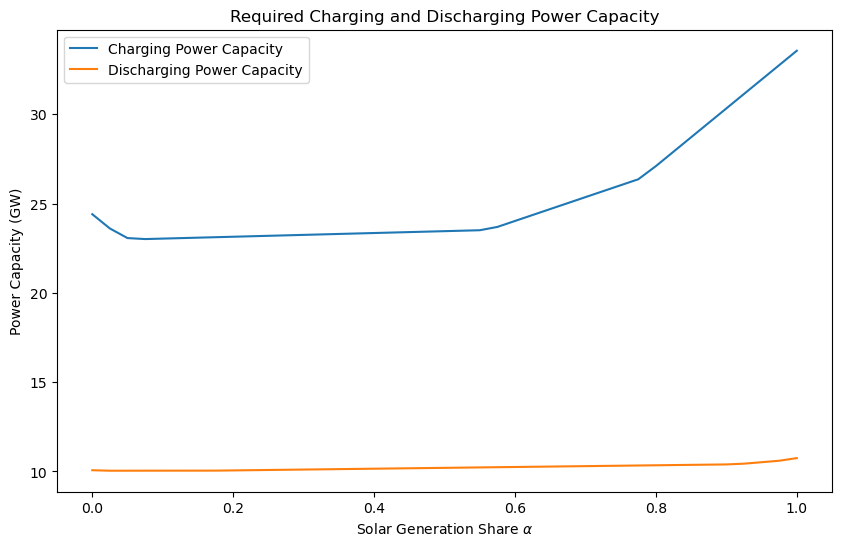

In [45]:
# YOUR CODE HERE
required_charging_power_capacity = (-df_alpha).max()
required_discharging_power_capacity = df_alpha.max()
plt.figure(figsize=(10, 6))
alphas = np.arange(0, 1.01, 0.025)
plt.plot(alphas, required_charging_power_capacity, label='Charging Power Capacity')
plt.plot(alphas, required_discharging_power_capacity, label='Discharging Power Capacity')
plt.title('Required Charging and Discharging Power Capacity')
plt.xlabel(r'Solar Generation Share $\alpha$')
plt.ylabel('Power Capacity (GW)')
# plt.xticks(required_charging_power_capacity.index[::8])
plt.legend()
plt.show()



**k)** Plot the required energy storage capacity (in TWh) as a function of the solar generation share $\alpha$. Choose appropriate labels. **(3 points)**

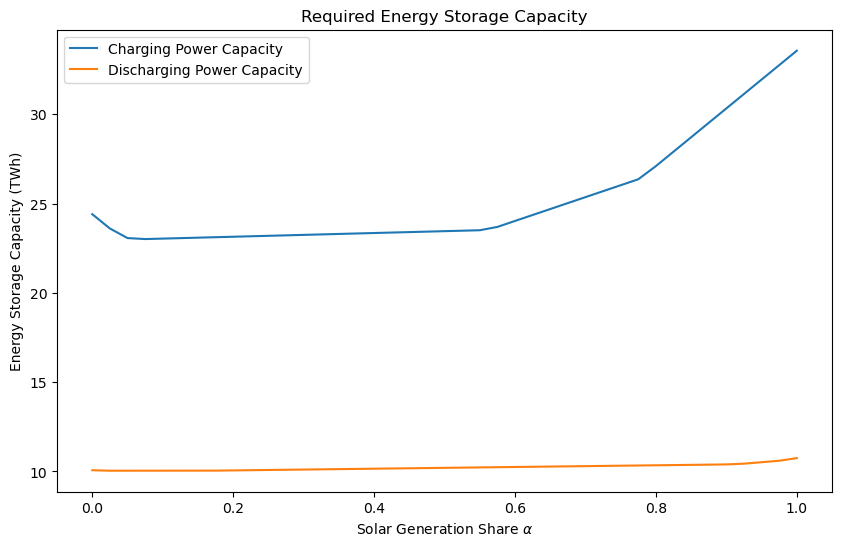

In [46]:
# YOUR CODE HERE
soc_alpha = (-df_alpha).cumsum()
energy_storage_capacity_alpha = (soc_alpha.max() - soc_alpha.min()) / 1000
plt.figure(figsize=(10, 6))
alphas = np.arange(0, 1.01, 0.025)
plt.plot(alphas, required_charging_power_capacity, label='Charging Power Capacity')
plt.plot(alphas, required_discharging_power_capacity, label='Discharging Power Capacity')
plt.title('Required Energy Storage Capacity')
plt.xlabel(r'Solar Generation Share $\alpha$')
plt.ylabel('Energy Storage Capacity (TWh)')
# plt.xticks(energy_storage_capacity_alpha.index[::8])
plt.legend()

**l)** Determine which of the considered generation mixes (i.e. which value of $\alpha$) results in the smallest required energy storage capacity. Return the value of $\alpha$ as a float. **(2 points)**

In [39]:
# YOUR CODE HERE
soc_alpha = (-df_alpha).cumsum()
energy_storage_capacities = soc_alpha.max() - soc_alpha.min()
optimal_alpha = float(energy_storage_capacities.idxmin().replace('alpha_', ''))
optimal_alpha


0.325

In [40]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**m)** Determine which of the considered generation mixes results in the smallest required charging power capacity. Return the value of $\alpha$ as a float. **(2 points)**

In [41]:
# YOUR CODE HERE
charging_power_capacity_alpha = (-df_alpha).max()
optimal_alpha_m = float(charging_power_capacity_alpha.idxmin().replace('alpha_', ''))
optimal_alpha_m

0.07500000000000001

In [42]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**n)** Plot the state of charge profiles (in TWh) for the energy-storage-optimal $\alpha$ from **l)** and the charging-power-optimal $\alpha$ from **m)**, and compare both to the wind-only and solar-only cases in a single figure with appropriate labels. **(3 points)**

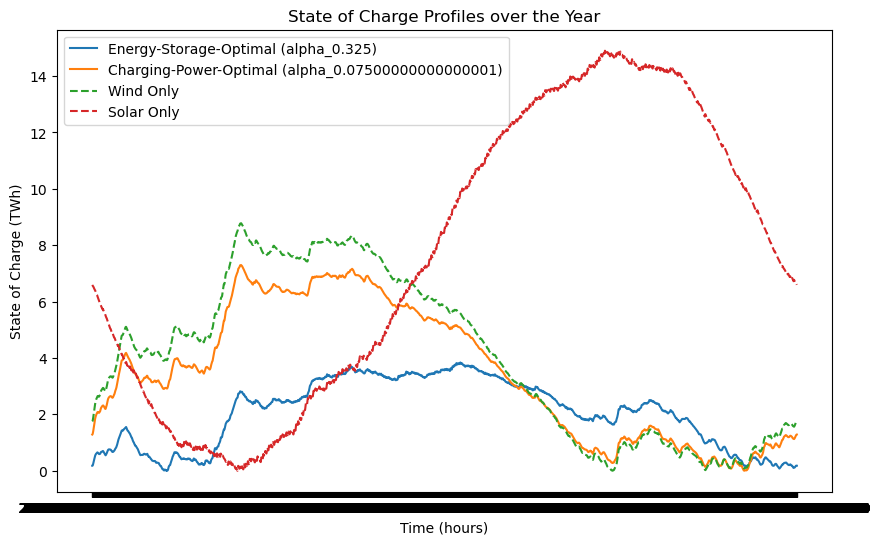

In [47]:
# YOUR CODE HERE
col_energy_opt = energy_storage_capacities.idxmin()
col_power_opt = charging_power_capacity_alpha.idxmin()
acc_energy = (-df_alpha[col_energy_opt]).cumsum() / 1000
soc_energy_optimal_twh = acc_energy - acc_energy.min()
acc_power = (-df_alpha[col_power_opt]).cumsum() / 1000
soc_power_optimal_twh = acc_power - acc_power.min()
plt.figure(figsize=(10, 6))
plt.plot(soc_energy_optimal_twh, label=f'Energy-Storage-Optimal ({col_energy_opt})')
plt.plot(soc_power_optimal_twh, label=f'Charging-Power-Optimal ({col_power_opt})')
plt.plot(soc_wind / 1000, label='Wind Only', linestyle='--')
plt.plot(soc_solar / 1000, label='Solar Only', linestyle='--')
plt.title('State of Charge Profiles over the Year')
plt.xlabel('Time (hours)')
plt.ylabel('State of Charge (TWh)')
plt.legend()
plt.show()
